In [35]:
# =========================================================
# 1. IMPORTS
# =========================================================

import tensorflow as tf
import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version : {tf.__version__}")
print(f"Pandas version     : {pd.__version__}")
print("Environnement prêt !")

TensorFlow version : 2.21.0
Pandas version     : 2.3.3
Environnement prêt !


In [36]:
# =========================================================
# 2. PARAMETRES GENERAUX
# =========================================================

IMAGE_SIZE = (32, 32)
BATCH_SIZE = 32
EPOCHS = 15
SEED = 42
N_CLASSES = 43

# Pour avoir des résultats reproductibles
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Pour l'affichage
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [37]:
# =========================================================
# 3. CHEMINS
#    Ici, le notebook Init.ipynb est au même niveau que GTSRB
# =========================================================

base_path = Path("GTSRB")

train_path = base_path / "Train"
test_path = base_path / "Test"
meta_path = base_path / "Meta"

train_csv_path = base_path / "Train.csv"
csv_path = base_path / "Test.csv"
meta_csv_path = base_path / "Meta.csv"

print("Train path :", train_path)
print("Test path  :", test_path)
print("Meta path  :", meta_path)

print("Train.csv trouvé :", train_csv_path.exists())
print("Test.csv trouvé  :", csv_path.exists())
print("Meta.csv trouvé  :", meta_csv_path.exists())

Train path : GTSRB\Train
Test path  : GTSRB\Test
Meta path  : GTSRB\Meta
Train.csv trouvé : True
Test.csv trouvé  : True
Meta.csv trouvé  : True


In [38]:
# =========================================================
# 4. CHARGEMENT DES CSV
# =========================================================

data = pd.read_csv(train_csv_path)
test_df = pd.read_csv(csv_path)
meta_df = pd.read_csv(meta_csv_path)

print("Taille data (train officiel) :", data.shape)
print("Taille test_df (test officiel) :", test_df.shape)
print("Taille meta_df :", meta_df.shape)

display(data.head())
display(test_df.head())

Taille data (train officiel) : (39209, 8)
Taille test_df (test officiel) : (12630, 8)
Taille meta_df : (43, 5)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [39]:
# =========================================================
# 5. CHEMINS COMPLETS DES IMAGES
#    Très important : on utilise les vrais labels ClassId des CSV
# =========================================================

data["full_path"] = data["Path"].apply(lambda x: str(base_path / x))
test_df["full_path"] = test_df["Path"].apply(lambda x: str(base_path / x))
meta_df["full_path"] = meta_df["Path"].apply(lambda x: str(base_path / x))

# Labels du train officiel
labels = data["ClassId"].values

display(data[["Path", "full_path", "ClassId"]].head())

,Path,full_path,ClassId
0,Train/20/00020_00000_00000.png,GTSRB\Train\20\00020_00000_00000.png,20
1,Train/20/00020_00000_00001.png,GTSRB\Train\20\00020_00000_00001.png,20
2,Train/20/00020_00000_00002.png,GTSRB\Train\20\00020_00000_00002.png,20
3,Train/20/00020_00000_00003.png,GTSRB\Train\20\00020_00000_00003.png,20
4,Train/20/00020_00000_00004.png,GTSRB\Train\20\00020_00000_00004.png,20


In [40]:
# =========================================================
# 6. VERIFICATION RAPIDE
# =========================================================

print("Nombre de classes dans le train :", data["ClassId"].nunique())
print("Classes présentes :", sorted(data["ClassId"].unique()))

Nombre de classes dans le train : 43
Classes présentes : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42)]


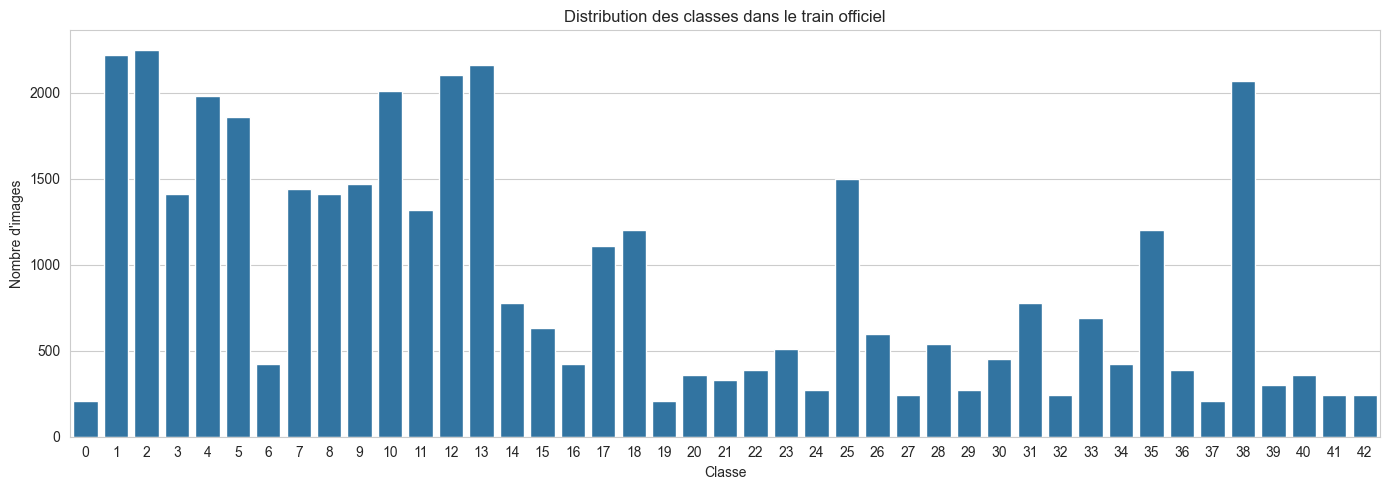

In [41]:
# =========================================================
# 7. DISTRIBUTION DES CLASSES
# =========================================================

distribution = data["ClassId"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.barplot(x=distribution.index, y=distribution.values)
plt.title("Distribution des classes dans le train officiel")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

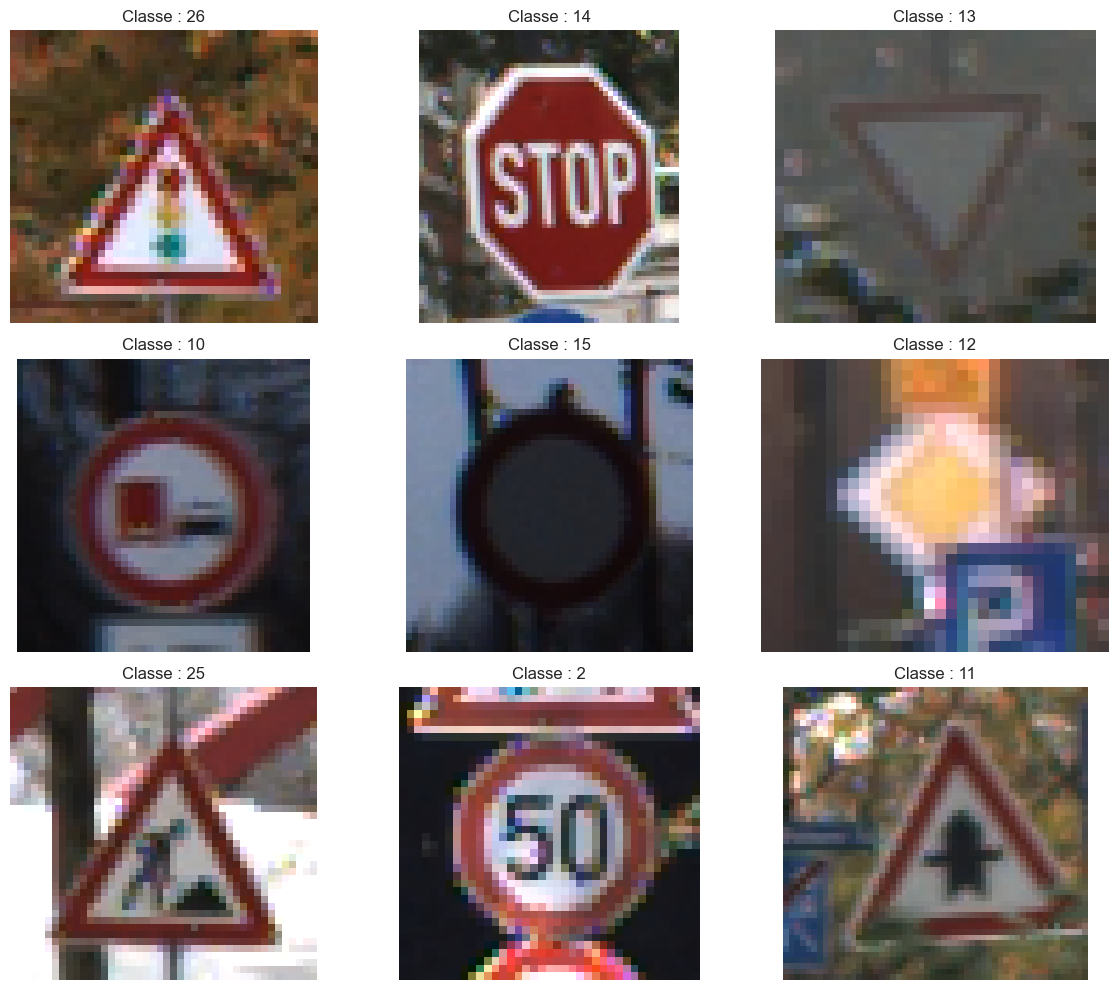

In [42]:
# =========================================================
# 8. AFFICHAGE DE QUELQUES IMAGES
#    Cela respecte la partie exploration / chargement avec PIL
# =========================================================

sample_df = data.sample(n=9, random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(12, 10))

for i in range(9):
    img_path = sample_df.loc[i, "full_path"]
    real_class = int(sample_df.loc[i, "ClassId"])

    img = Image.open(img_path).convert("RGB")

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Classe : {real_class}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [43]:
# =========================================================
# 9. DIVISION DU TRAIN OFFICIEL EN TRAIN + VALIDATION
#    Le test officiel reste intact
# =========================================================

X_train, X_val = train_test_split(
    data,
    test_size=0.20,
    random_state=SEED,
    stratify=data["ClassId"]
)

# Le test officiel reste séparé
X_test = test_df.copy()

# Labels correspondants
y_train = X_train["ClassId"].values
y_val = X_val["ClassId"].values
y_test = X_test["ClassId"].values

# Réindexation propre
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

print("Taille X_train :", X_train.shape)
print("Taille X_val   :", X_val.shape)
print("Taille X_test  :", X_test.shape)

Taille X_train : (31367, 9)
Taille X_val   : (7842, 9)
Taille X_test  : (12630, 9)


In [44]:
# =========================================================
# 10. GENERATEUR DE DONNEES
#     Il lit les images par lots pour éviter de tout charger
#     en mémoire en une seule fois
# =========================================================

class TrafficSignGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, shuffle=True):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.batch_size = batch_size
        self.image_size = image_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.dataframe))
        self.on_epoch_end()

    def __len__(self):
        # Nombre de lots par époque
        return int(np.ceil(len(self.dataframe) / self.batch_size))

    def __getitem__(self, index):
        # Sélection des indices du lot
        start = index * self.batch_size
        end = min((index + 1) * self.batch_size, len(self.dataframe))
        batch_indices = self.indices[start:end]

        batch_df = self.dataframe.iloc[batch_indices]

        # Tableaux du lot
        batch_images = np.zeros(
            (len(batch_df), self.image_size[0], self.image_size[1], 3),
            dtype=np.float32
        )
        batch_labels = batch_df["ClassId"].astype(np.int32).values

        # Lecture image par image
        for i, path in enumerate(batch_df["full_path"]):
            img = Image.open(path).convert("RGB")
            img = img.resize(self.image_size)

            img_array = np.array(img, dtype=np.float32) / 255.0
            batch_images[i] = img_array

        return batch_images, batch_labels

    def on_epoch_end(self):
        # Mélange à la fin de chaque époque
        if self.shuffle:
            np.random.shuffle(self.indices)

In [45]:
# =========================================================
# 11. CREATION DES GENERATEURS
# =========================================================

train_generator = TrafficSignGenerator(
    X_train,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True
)

val_generator = TrafficSignGenerator(
    X_val,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=False
)

test_generator = TrafficSignGenerator(
    X_test,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=False
)

print("Nombre de lots train :", len(train_generator))
print("Nombre de lots val   :", len(val_generator))
print("Nombre de lots test  :", len(test_generator))

Nombre de lots train : 981
Nombre de lots val   : 246
Nombre de lots test  : 395


In [46]:
# =========================================================
# 12. VERIFICATION D'UN LOT
# =========================================================

batch_images, batch_labels = train_generator[0]

print("Forme batch_images :", batch_images.shape)
print("Forme batch_labels :", batch_labels.shape)
print("Quelques labels    :", batch_labels[:10])

Forme batch_images : (32, 32, 32, 3)
Forme batch_labels : (32,)
Quelques labels    : [21 22 20  8 24  4  3  9  5  2]


In [47]:
# =========================================================
# 13. CONSTRUCTION DU MODELE CNN
#     On utilise bien TensorFlow / Keras
# =========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),

    # Bloc 1
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    # Bloc 2
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    # Bloc 3
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    # Passage vers les couches denses
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.4),

    # Couche de sortie
    Dense(N_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape         ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)           │ (None, 32, 32, 32)   │         896 │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ max_pooling2d_4             │ (None, 16, 16, 32)   │           0 │
│ (MaxPooling2D)              │                      │             │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ conv2d_5 (Conv2D)           │ (None, 16, 16, 64)   │      18,496 │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ max_pooling2d_5             │ (None, 8, 8, 64)     │           0 │
│ (MaxPooling2D)              │                      │             │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ conv2d_6 (Conv2D)           │ (None, 8, 8, 128)    │      73,856 │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ max_pooling2d_6             │ (None, 4, 4, 128)    │           0 │
│ (MaxPooling2D)              │                      │             │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ flatten_2 (Flatten)         │ (None, 2048)         │           0 │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ dense_4 (Dense)             │ (None, 128)          │     262,272 │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ dropout_2 (Dropout)         │ (None, 128)          │           0 │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ dense_5 (Dense)             │ (None, 43)           │       5,547 │
└─────────────────────────────┴──────────────────────┴─────────────┘

 Total params: 361,067 (1.38 MB)

 Trainable params: 361,067 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# =========================================================
# 14. COMPILATION DU MODELE
#     Adam + sparse_categorical_crossentropy
#     car les labels sont des entiers (0 à 42)
# =========================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [49]:
# =========================================================
# 15. CALLBACKS
#     EarlyStopping : arrête si la validation ne progresse plus
#     ReduceLROnPlateau : baisse le learning rate si besoin
# =========================================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

In [50]:
# =========================================================
# 16. ENTRAINEMENT
# =========================================================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 155s 152ms/step - accuracy: 0.4397 - loss: 1.8895 - val_accuracy: 0.8484 - val_loss: 0.5189 - learning_rate: 0.0010
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 95s 96ms/step - accuracy: 0.8329 - loss: 0.4997 - val_accuracy: 0.9633 - val_loss: 0.1496 - learning_rate: 0.0010
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 94s 96ms/step - accuracy: 0.9233 - loss: 0.2385 - val_accuracy: 0.9800 - val_loss: 0.0756 - learning_rate: 0.0010
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 95s 96ms/step - accuracy: 0.9516 - loss: 0.1490 - val_accuracy: 0.9850 - val_loss: 0.0599 - learning_rate: 0.0010
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 142s 97ms/step - accuracy: 0.9617 - loss: 0.1155 - val_accuracy: 0.9895 - val_loss: 0.0414 - learning_rate: 0.0010
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 95s 96ms/step - accuracy: 0.9720 - loss: 0.0844 - val_accuracy: 0.9916 - val_loss: 0.0332 - learning_rate: 0.0010
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 95s 97ms/step - accuracy: 0.9777 

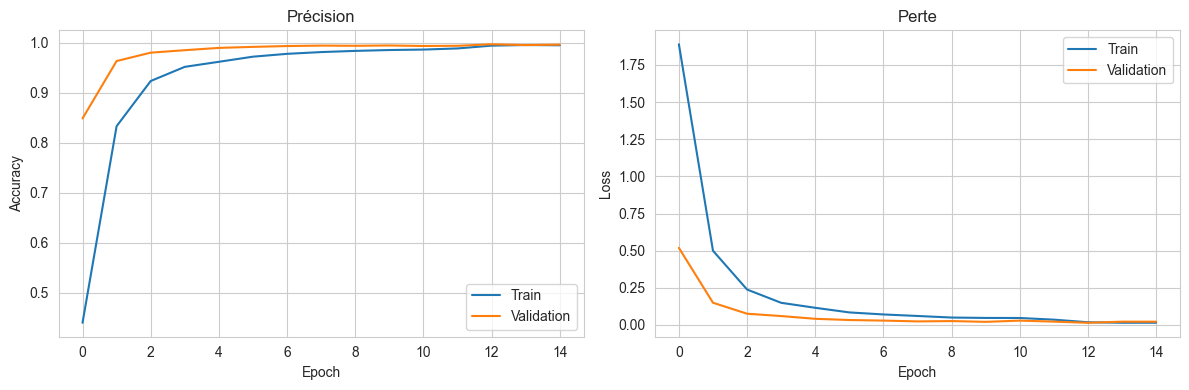

In [51]:
# =========================================================
# 17. COURBES D'APPRENTISSAGE
# =========================================================

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Précision")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Perte")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [52]:
# =========================================================
# 18. EVALUATION SUR L'ENSEMBLE DE VALIDATION
# =========================================================

val_loss, val_acc = model.evaluate(val_generator, verbose=1)

print(f"Loss validation     : {val_loss:.4f}")
print(f"Accuracy validation : {val_acc:.4f}")

246/246 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.9968 - loss: 0.0145
Loss validation     : 0.0145
Accuracy validation : 0.9968


In [53]:
# =========================================================
# 19. EVALUATION SUR LE TEST OFFICIEL
# =========================================================

loss, acc = model.evaluate(test_generator, verbose=1)

print(f"Loss test     : {loss:.4f}")
print(f"Accuracy test : {acc:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 317s 805ms/step - accuracy: 0.9601 - loss: 0.2382
Loss test     : 0.2382
Accuracy test : 0.9601


In [54]:
# =========================================================
# 20. PREDICTIONS SUR LE TEST OFFICIEL
# =========================================================

y_pred_proba = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

print("Nombre de vraies étiquettes :", len(y_test))
print("Nombre de prédictions       :", len(y_pred))

395/395 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step
Nombre de vraies étiquettes : 12630
Nombre de prédictions       : 12630


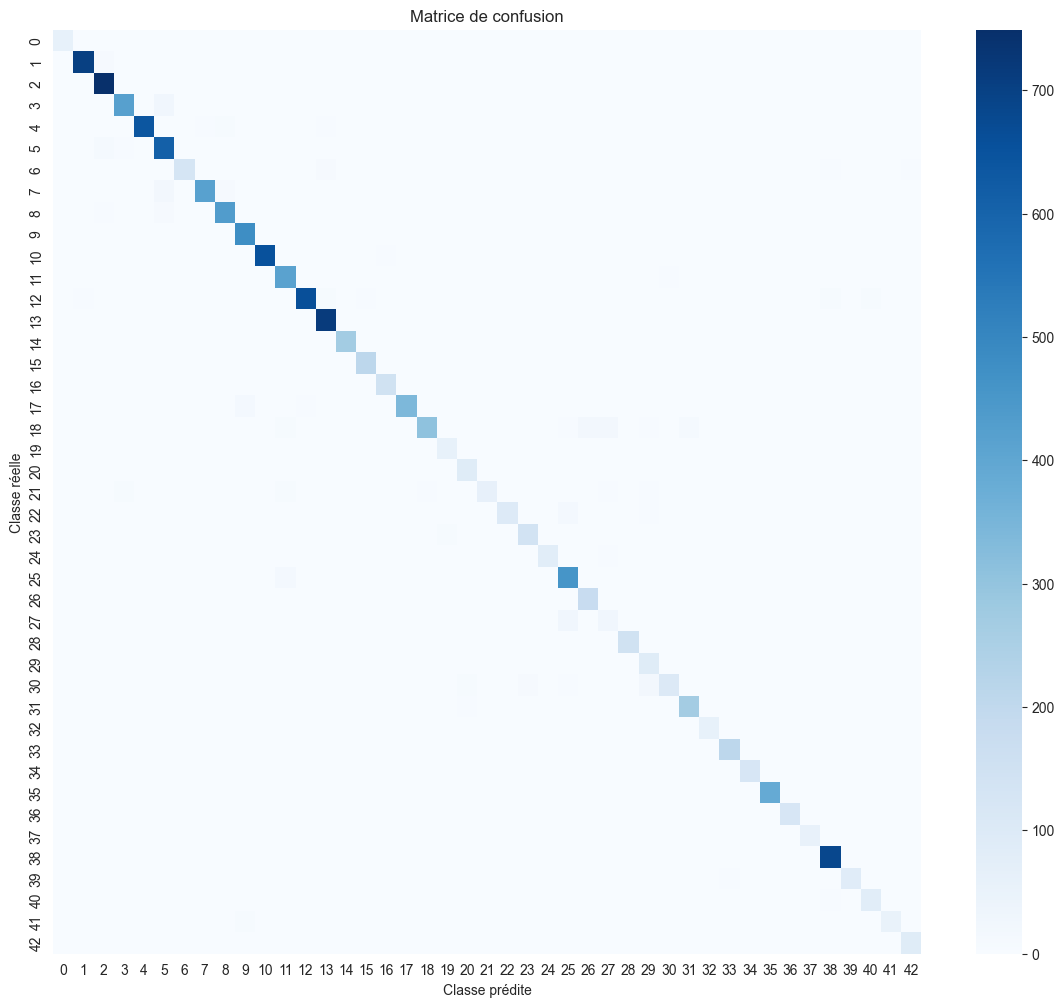

In [55]:
# =========================================================
# 21. MATRICE DE CONFUSION
# =========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

In [56]:
# =========================================================
# 22. RAPPORT DE CLASSIFICATION
# =========================================================

print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9375    1.0000    0.9677        60
           1     0.9930    0.9792    0.9860       720
           2     0.9640    0.9987    0.9810       750
           3     0.9700    0.9333    0.9513       450
           4     0.9969    0.9697    0.9831       660
           5     0.9064    0.9683    0.9363       630
           6     1.0000    0.8733    0.9324       150
           7     0.9835    0.9244    0.9530       450
           8     0.9560    0.9667    0.9613       450
           9     0.9523    0.9979    0.9746       480
          10     0.9969    0.9894    0.9932       660
          11     0.9200    0.9857    0.9517       420
          12     0.9880    0.9580    0.9728       690
          13     0.9624    0.9944    0.9781       720
          14     1.0000    1.0000    1.0000       270
          15     0.9722    1.0000    0.9859       210
          16     0.9803    0.9933    0.9868       150
          17     1.0000    

In [57]:
# =========================================================
# 23. FONCTION DE PREDICTION SUR UNE IMAGE
# =========================================================

def predire_une_image(img_path):
    # Chargement de l'image
    img = Image.open(img_path).convert("RGB")
    img_resized = img.resize(IMAGE_SIZE)

    # Prétraitement
    img_array = np.array(img_resized, dtype=np.float32) / 255.0
    img_array = img_array.reshape(1, IMAGE_SIZE[0], IMAGE_SIZE[1], 3)

    # Prédiction
    prediction = model.predict(img_array, verbose=0)
    predicted_class = int(np.argmax(prediction))
    confidence = float(np.max(prediction))

    return img, predicted_class, confidence

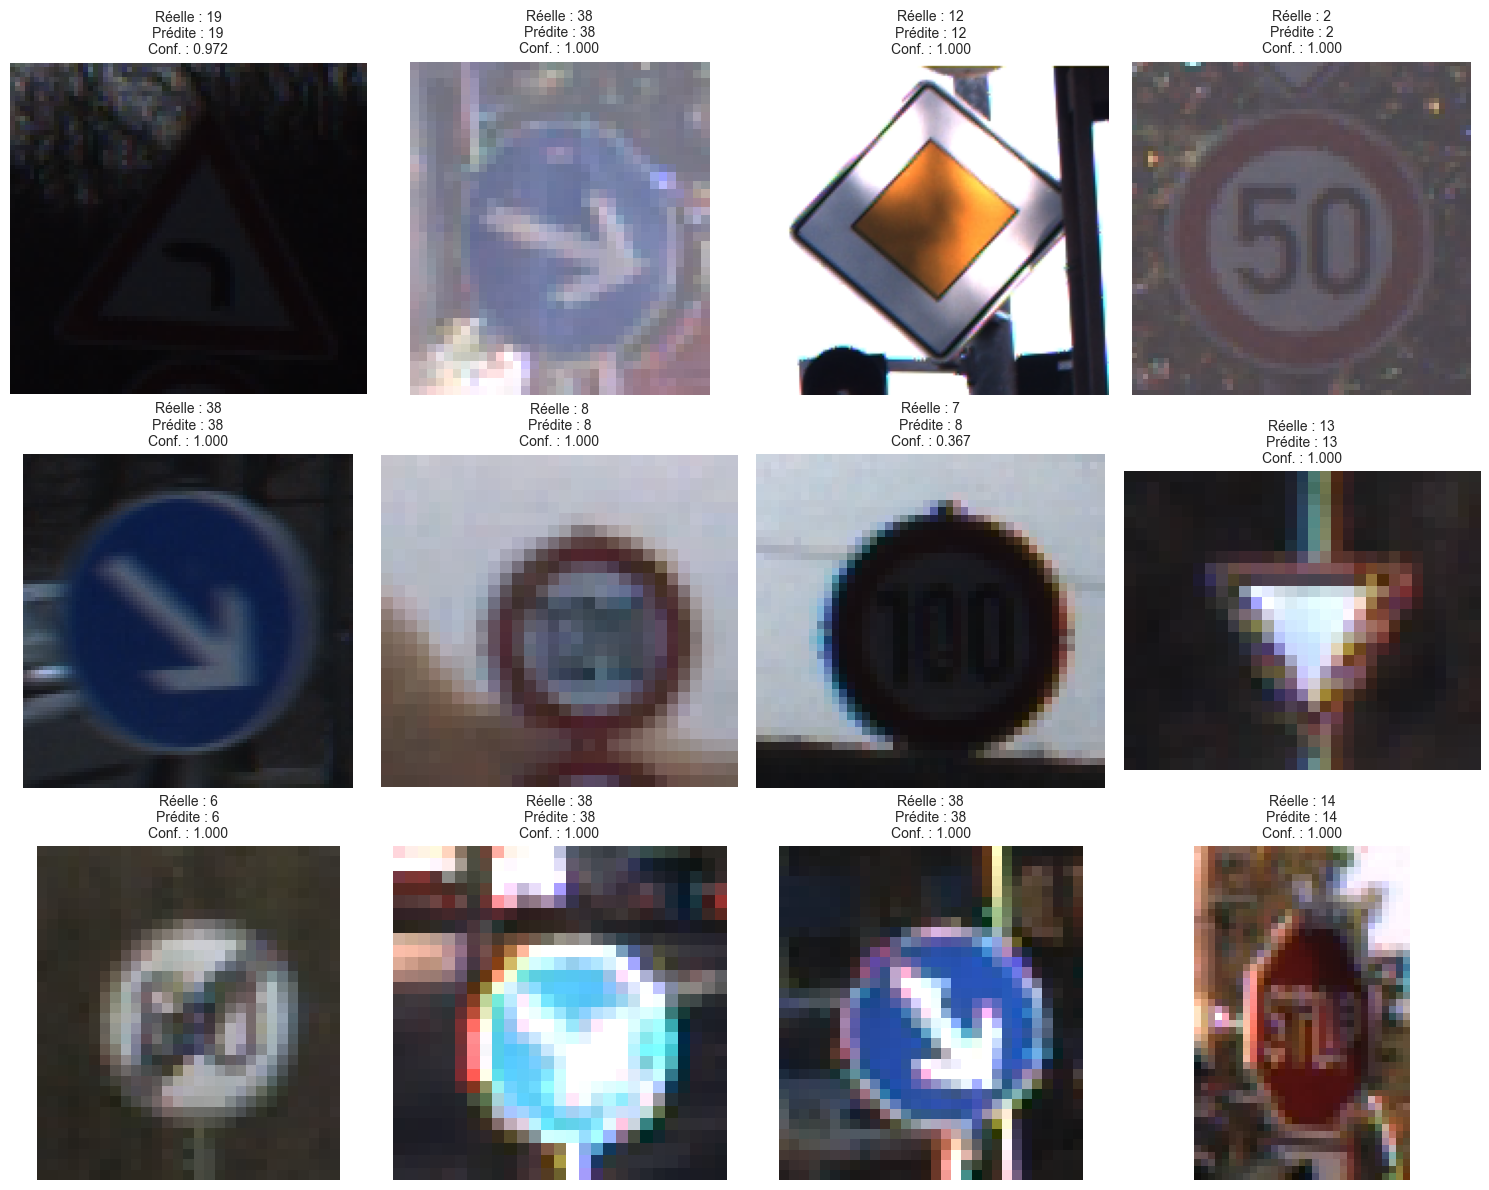

In [58]:
# =========================================================
# 24. TEST SUR QUELQUES IMAGES ALEATOIRES DU TEST
# =========================================================

nombre_images = min(12, len(test_df))

# Sans random_state : images différentes à chaque exécution
echantillon_test = test_df.sample(n=nombre_images).reset_index(drop=True)

plt.figure(figsize=(15, 12))

for i in range(len(echantillon_test)):
    random_row = echantillon_test.loc[i]

    img_path = random_row["full_path"]
    real_class = int(random_row["ClassId"])

    img, predicted_class, confidence = predire_une_image(img_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(
        f"Réelle : {real_class}\nPrédite : {predicted_class}\nConf. : {confidence:.3f}",
        fontsize=10
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

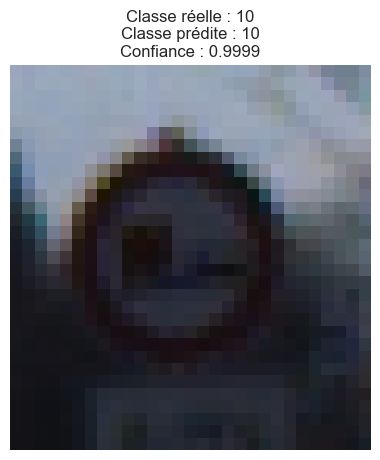

In [60]:
# =========================================================
# 25. TEST SUR UNE SEULE IMAGE ALEATOIRE
# =========================================================

random_row = test_df.sample(1).iloc[0]

img_path = random_row["full_path"]
real_class = int(random_row["ClassId"])

img, predicted_class, confidence = predire_une_image(img_path)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(
    f"Classe réelle : {real_class}\n"
    f"Classe prédite : {predicted_class}\n"
    f"Confiance : {confidence:.4f}"
)
plt.axis("off")
plt.show()